In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/nomanporag/bank-loan/Bank_Personal_Loan_Modelling(1).csv') 
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (5000, 14)

Columns: ['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [ ]:
# ================== DATA CLEANING ==================

# 1. Drop ID column (if exists)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# 2. Handle Negative Experience
if 'Experience' in df.columns:
    print("Negative Experience count before:", (df['Experience'] < 0).sum())
    df['Experience'] = df['Experience'].clip(lower=0)





Negative Experience count before: 52


In [ ]:
# 3. Fix ZIP Code (robust cleaning)
if 'ZIP Code' in df.columns:
    print("\nBefore Fix - ZIP Code Sample:")
    print(df['ZIP Code'].head(10))

    # Convert to string and remove invalid characters like '/'
    df['ZIP Code'] = df['ZIP Code'].astype(str).str.replace('/', '', regex=True)

    # Convert to numeric (invalid → NaN)
    df['ZIP Code'] = pd.to_numeric(df['ZIP Code'], errors='coerce')

    print("\nMissing ZIP after cleaning:", df['ZIP Code'].isnull().sum())

    # Fill missing with median
    df['ZIP Code'] = df['ZIP Code'].fillna(df['ZIP Code'].median())

    # Convert to int
    df['ZIP Code'] = df['ZIP Code'].astype(int)

    print("Final ZIP Code dtype:", df['ZIP Code'].dtype)

# 4. Education → categorical
if 'Education' in df.columns:
    df['Education'] = df['Education'].astype('category')


Before Fix - ZIP Code Sample:
0    91107
1    90089
2    94720
3    94112
4    91330
5    92121
6    91711
7    93943
8    90089
9    93023
Name: ZIP Code, dtype: int64

Missing ZIP after cleaning: 0
Final ZIP Code dtype: int64


In [ ]:
# ================== FINAL CHECK ==================

print("\nAfter Cleaning:")
print("Shape:", df.shape)

print("\nMissing Values:\n", df.isnull().sum())

if 'Experience' in df.columns:
    print("\nNegative Experience now:", (df['Experience'] < 0).sum())

# Summary stats
print("\nDataset Description:")
print(df.describe())

# Target distribution (if exists)
if 'Personal Loan' in df.columns:
    print("\nPersonal Loan Distribution:")
    print(df['Personal Loan'].value_counts())

    print("\nPercentage:")
    print(df['Personal Loan'].value_counts(normalize=True) * 100)


After Cleaning:
Shape: (5000, 13)

Missing Values:
 Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Negative Experience now: 0

Dataset Description:
               Age   Experience       Income      ZIP Code       Family  \
count  5000.000000  5000.000000  5000.000000   5000.000000  5000.000000   
mean     45.338400    20.119600    73.774200  93152.503000     2.396400   
std      11.463166    11.440484    46.033729   2121.852197     1.147663   
min      23.000000     0.000000     8.000000   9307.000000     1.000000   
25%      35.000000    10.000000    39.000000  91911.000000     1.000000   
50%      45.000000    20.000000    64.000000  93437.000000     2.000000   
75%      55.000000    30.000000    98.000000  9

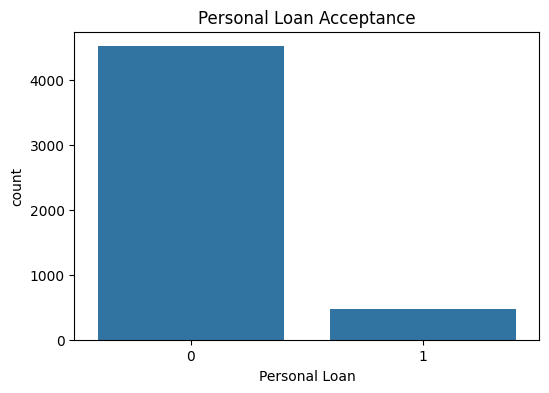


🔥 Correlation with Personal Loan:

Personal Loan         1.000000
Income                0.502462
CD Account            0.316355
Mortgage              0.142095
Family                0.061367
Securities Account    0.021954
Online                0.006278
CreditCard            0.002802
ZIP Code              0.000107
Age                  -0.007726
Experience           -0.007858
Name: Personal Loan, dtype: float64


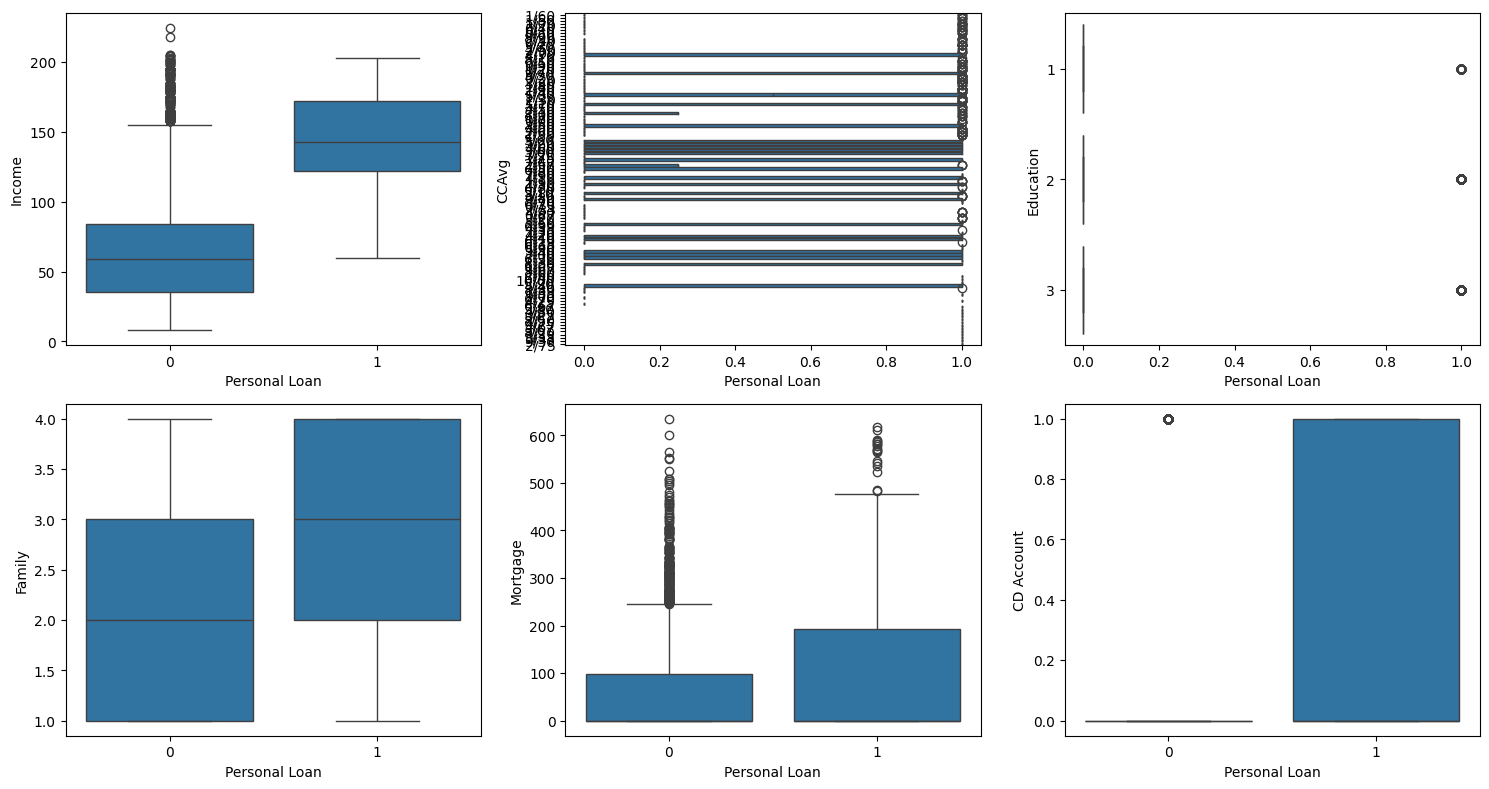

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Personal Loan', data=df)
plt.title('Personal Loan Acceptance')
plt.show()

# Correlation
corr = df.corr(numeric_only=True)['Personal Loan'].sort_values(ascending=False)
print("\n🔥 Correlation with Personal Loan:\n")
print(corr)

# Top features visualization
top_features = ['Income', 'CCAvg', 'Education', 'Family', 'Mortgage', 'CD Account']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feature in enumerate(top_features):
    row, col = divmod(i, 3)
    sns.boxplot(x='Personal Loan', y=feature, data=df, ax=axes[row, col])
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   ZIP Code            5000 non-null   int64   
 4   Family              5000 non-null   int64   
 5   CCAvg               5000 non-null   object  
 6   Education           5000 non-null   category
 7   Mortgage            5000 non-null   int64   
 8   Personal Loan       5000 non-null   int64   
 9   Securities Account  5000 non-null   int64   
 10  CD Account          5000 non-null   int64   
 11  Online              5000 non-null   int64   
 12  CreditCard          5000 non-null   int64   
dtypes: category(1), int64(11), object(1)
memory usage: 473.9+ KB


In [ ]:
import pandas as pd

# ================== 1. CCAvg CUSTOM CLEAN ==================

month_map = {
    'Jan': '1', 'Feb': '2', 'Mar': '3', 'Apr': '4',
    'May': '5', 'Jun': '6', 'Jul': '7', 'Aug': '8',
    'Sep': '9', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}

def clean_ccavg(val):
    val = str(val)

    # Case 1: Jan-60
    if '-' in val:
        parts = val.split('-')
        if len(parts) == 2:
            part1, part2 = parts

            if part1 in month_map:
                return float(month_map[part1] + '.' + part2)

            elif part2 in month_map:
                return float(part1 + '.' + month_map[part2])

    # Case 2: 0/40
    if '/' in val:
        parts = val.split('/')
        if len(parts) == 2:
            return float(parts[0] + '.' + parts[1])

    # Default case
    try:
        return float(val)
    except:
        return None


# Apply CCAvg cleaning
if 'CCAvg' in df.columns:
    print("Cleaning CCAvg...")
    df['CCAvg'] = df['CCAvg'].apply(clean_ccavg)


# ================== 2. OTHER COLUMNS GENERIC CLEAN ==================

print("\nColumns with object dtype:")
print(df.select_dtypes(include='object').columns.tolist())

for col in df.select_dtypes(include='object').columns:
    if col != 'CCAvg':   # 🔥 Skip CCAvg
        print(f"\nCleaning {col}...")
        df[col] = df[col].astype(str).str.replace('/', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')


# ================== 3. HANDLE MISSING VALUES ==================

print("\nMissing values before fill:")
print(df.isnull().sum())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after fill:")
print(df.isnull().sum())


# ================== 4. FINAL DATA TYPE CHECK ==================

print("\nFinal Data Types:")
print(df.dtypes)

print("\nAny remaining object columns?")
print(df.select_dtypes(include='object').columns.tolist())


# ================== 5. QUICK PREVIEW ==================

print("\nCleaned Dataset Sample:")
print(df.head())

Cleaning CCAvg...

Columns with object dtype:
[]

Missing values before fill:
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Missing values after fill:
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Final Data Types:
Age                      int64
Experience               int64
Income                   int64
ZIP Code                 int64
Family                   int64
CCAvg                  float64
Education             category
Mortgage

In [ ]:
# ================== HANDLE CATEGORICAL COLUMN ==================

# Convert Education to numeric first (if needed)
df['Education'] = df['Education'].astype(int)

# One-Hot Encoding for Education
df = pd.get_dummies(df, columns=['Education'], prefix='Edu', drop_first=True)

print("After One-Hot Encoding:")
print(df.columns.tolist())
print(df.dtypes)

After One-Hot Encoding:
['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard', 'Edu_2', 'Edu_3']
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
Edu_2                    bool
Edu_3                    bool
dtype: object


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df.drop('Personal Loan', axis=1)
y = df['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
                                                    random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("✅ Preprocessing Successful!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("After SMOTE shape:", X_train_res.shape)

✅ Preprocessing Successful!
X_train_scaled shape: (4000, 13)
After SMOTE shape: (7232, 13)


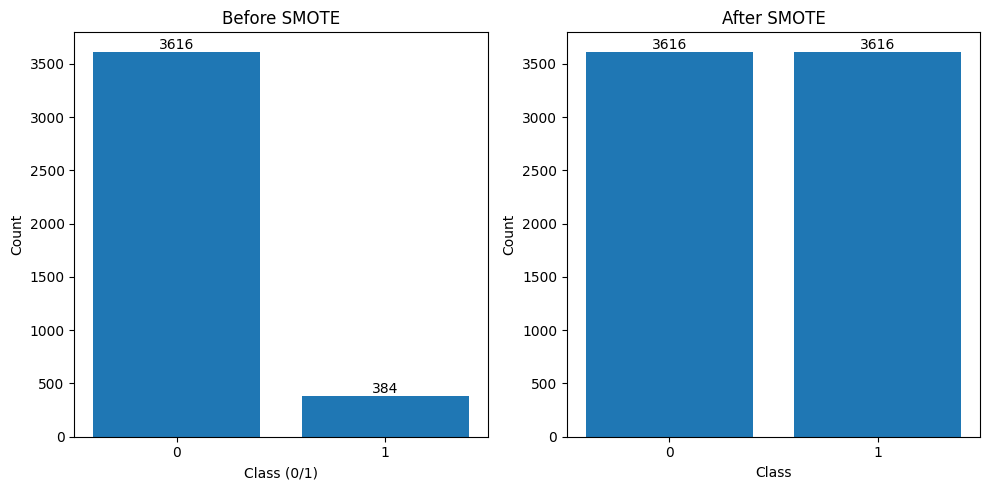

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Count values
before_counts = y_train.value_counts().sort_index()
after_counts = pd.Series(y_train_res).value_counts().sort_index()

# Create subplot
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# ===== BEFORE SMOTE =====
bars1 = axes[0].bar(before_counts.index.astype(str), before_counts.values)
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class (0/1)")
axes[0].set_ylabel("Count")

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height,
                 f'{int(height)}', ha='center', va='bottom')

# ===== AFTER SMOTE =====
bars2 = axes[1].bar(after_counts.index.astype(str), after_counts.values)
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

# Add value labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height,
                 f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Roll 40 model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Model Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)



LogisticRegression(max_iter=1000, random_state=42)

=== Logistic Regression ===
Accuracy : 90.80%
ROC-AUC  : 0.9674

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95       904
           1       0.51      0.92      0.66        96

    accuracy                           0.91      1000
   macro avg       0.75      0.91      0.80      1000
weighted avg       0.94      0.91      0.92      1000



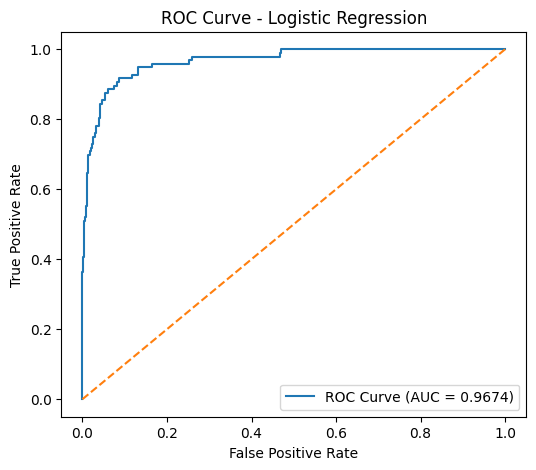

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Prediction
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# ================== ROC CURVE ==================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Confusion Matrix:
 [[820  84]
 [  8  88]]


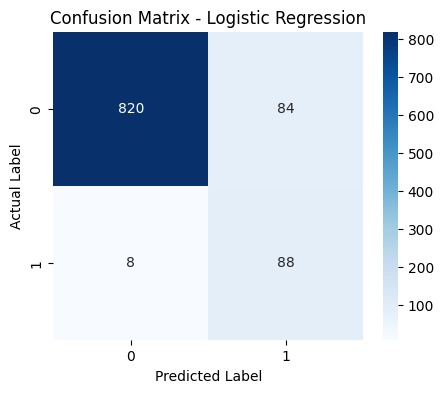

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:\n", cm)

# Heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

[[TN  FP]
 [FN  TP]]

 TN (0 correctly predicted)
FP (0 কে 1 predict করে ভুল)
FN (1 কে 0 predict করে miss)
TP (1 correctly predicted)

new model

# Roll 09 Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train_res, y_train_res)


RandomForestClassifier(max_depth=8, n_estimators=400, random_state=42)

=== Random Forest ===
Accuracy : 98.00%
ROC-AUC  : 0.9963

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95       904
           1       0.51      0.92      0.66        96

    accuracy                           0.91      1000
   macro avg       0.75      0.91      0.80      1000
weighted avg       0.94      0.91      0.92      1000



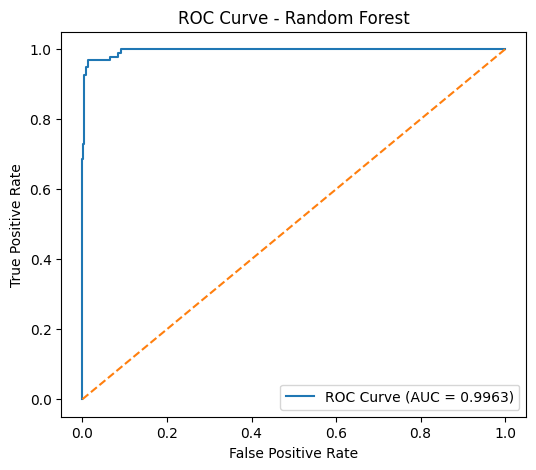

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Prediction
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf )*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf ):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# ================== ROC CURVE ==================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf )

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_rf ):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

Confusion Matrix:
 [[887  17]
 [  3  93]]


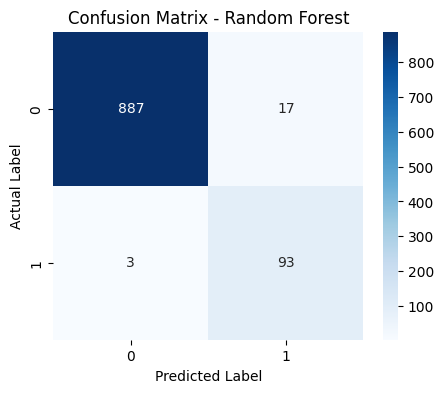

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf )

print("Confusion Matrix:\n", cm)

# Heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

new model 3 

# #Roll 23 model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train_res, y_train_res)


GradientBoostingClassifier(learning_rate=0.08, max_depth=5, n_estimators=300,
                           random_state=42)

=== Gradient Boosting ===
Accuracy : 98.80%
ROC-AUC  : 0.9993

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       904
           1       0.90      0.99      0.94        96

    accuracy                           0.99      1000
   macro avg       0.95      0.99      0.97      1000
weighted avg       0.99      0.99      0.99      1000



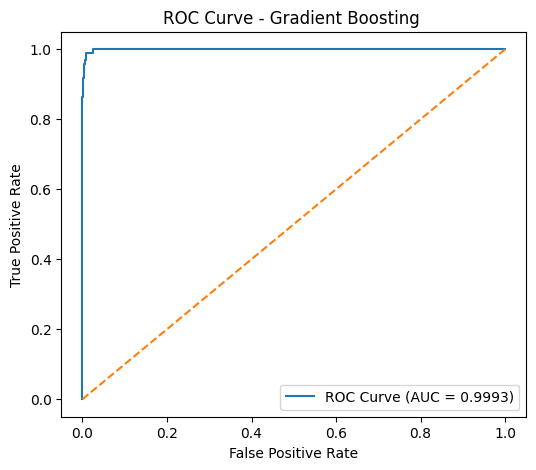

In [ ]:

y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("=== Gradient Boosting ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# ================== ROC CURVE ==================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_gb):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting ")
plt.legend()
plt.show()

Confusion Matrix:
 [[893  11]
 [  1  95]]


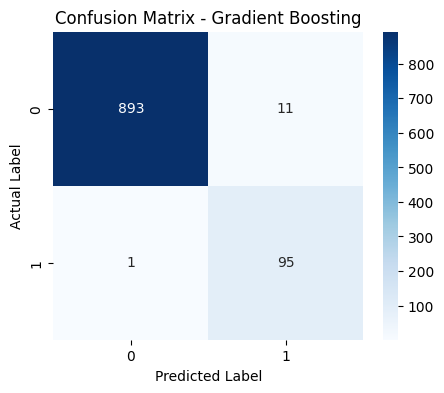

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

print("Confusion Matrix:\n", cm)

# Heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

model 4

# #Roll 34 model

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    random_state=42,
    eval_metric='auc'
)
xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

=== xgboost ===
Accuracy : 98.60%
ROC-AUC  : 0.9991

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       904
           1       0.90      0.96      0.93        96

    accuracy                           0.99      1000
   macro avg       0.95      0.97      0.96      1000
weighted avg       0.99      0.99      0.99      1000



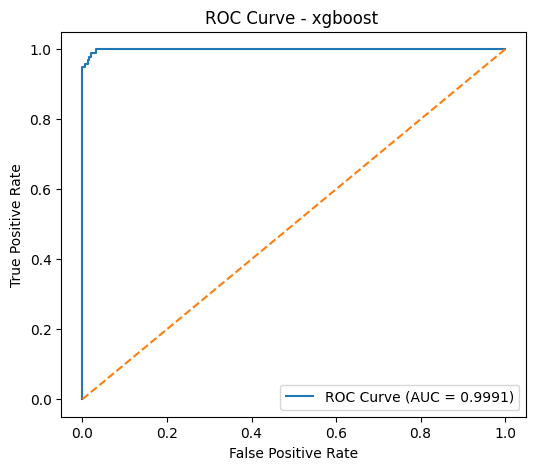

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("=== xgboost ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# ================== ROC CURVE ==================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - xgboost ")
plt.legend()
plt.show()

Confusion Matrix:
 [[894  10]
 [  4  92]]


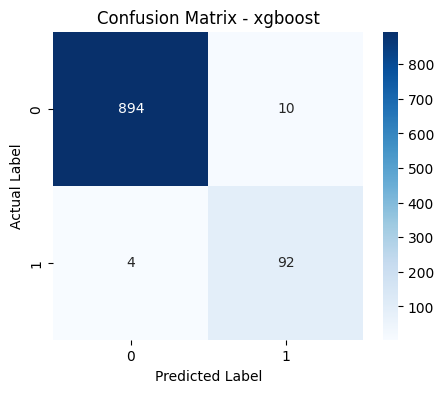

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:\n", cm)

# Heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - xgboost")
plt.show()

ml 5

# ROll 56 model

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# ================== MODEL ==================
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

# ================== TRAINING ==================
lgbm_model.fit(X_train_res, y_train_res)


[LightGBM] [Info] Number of positive: 3616, number of negative: 3616
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2175
[LightGBM] [Info] Number of data points in the train set: 7232, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

=== lightgbm ===
Accuracy : 98.80%
ROC-AUC  : 0.9990

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       904
           1       0.93      0.95      0.94        96

    accuracy                           0.99      1000
   macro avg       0.96      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


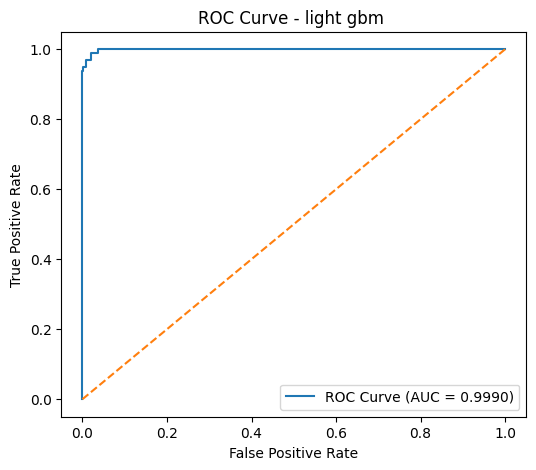

In [ ]:
# Predict
y_pred_lgm = lgbm_model.predict(X_test_scaled)
y_prob_lgm = lgbm_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("=== lightgbm ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lgm)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lgm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgm))

# ================== ROC CURVE ==================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgm)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_lgm):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - light gbm ")
plt.legend()
plt.show()

Confusion Matrix:
 [[897   7]
 [  5  91]]


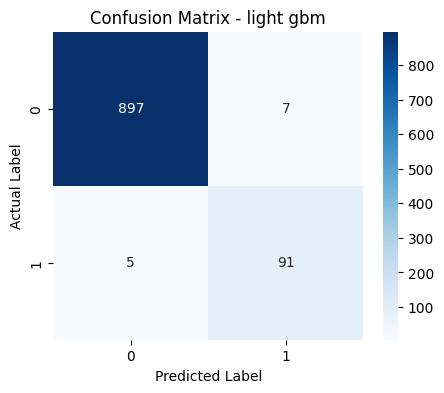

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lgm)

print("Confusion Matrix:\n", cm)

# Heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - light gbm")
plt.show()

# ROll 15 Model

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42,
    C=1.0,
    gamma='scale'
)

svm_model.fit(X_train_res, y_train_res)

SVC(probability=True, random_state=42)

=== SVM ===
Accuracy : 97.30%
ROC-AUC  : 0.9940

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       904
           1       0.79      0.97      0.87        96

    accuracy                           0.97      1000
   macro avg       0.90      0.97      0.93      1000
weighted avg       0.98      0.97      0.97      1000



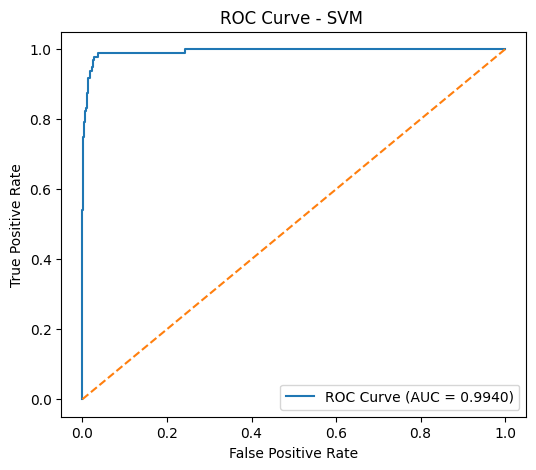

In [ ]:
# Predict
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("=== SVM ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# ================== ROC CURVE ==================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_svm):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM ")
plt.legend()
plt.show()

Confusion Matrix:
 [[880  24]
 [  3  93]]


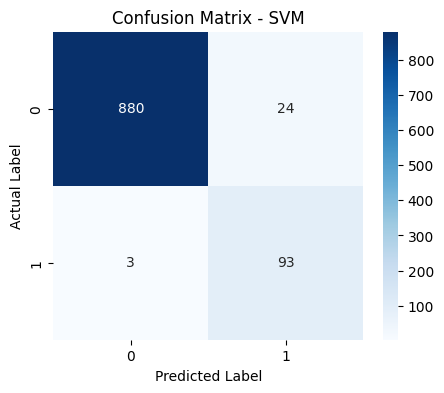

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:\n", cm)

# Heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SVM")
plt.show()

ml6


# ROll 27 model

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

# ================== MODEL ==================
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ================== TRAINING ==================
history = mlp_model.fit(
    X_train_res,
    y_train_res,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)



2026-04-17 06:05:29.270166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776405929.293626     822 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776405929.301069     822 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776405929.319485     822 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776405929.319507     822 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776405929.319510     822 computation_placer.cc:177] computation placer alr

Epoch 1/20


I0000 00:00:1776405937.288320     893 service.cc:152] XLA service 0x794578012180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776405937.288349     893 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776405937.288353     893 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776405937.500764     893 cuda_dnn.cc:529] Loaded cuDNN version 91002


 73/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6098 - loss: 0.6541

I0000 00:00:1776405938.101486     893 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7349 - loss: 0.5170 - val_accuracy: 0.9413 - val_loss: 0.1965
Epoch 2/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9439 - loss: 0.1552 - val_accuracy: 0.9641 - val_loss: 0.1355
Epoch 3/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9658 - loss: 0.1001 - val_accuracy: 0.9648 - val_loss: 0.1304
Epoch 4/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9691 - loss: 0.0846 - val_accuracy: 0.9661 - val_loss: 0.1150
Epoch 5/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9771 - loss: 0.0723 - val_accuracy: 0.9758 - val_loss: 0.0945
Epoch 6/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9819 - loss: 0.0613 - val_accuracy: 0.9730 - val_loss: 0.0854
Epoch 7/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9840 - loss: 0.0514 - val_accuracy: 0.9806 - val_loss: 0.0659
Epoch 8/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9833 - loss: 0.0504 - val_accuracy: 0.9710 - val

In [ ]:
# ================== PREDICTION ==================
y_prob_MLP = mlp_model.predict(X_test_scaled)
y_pred_MLP = (y_prob_MLP > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


=== MLP (Deep Learning) ===
Accuracy : 97.90%
ROC-AUC  : 0.9943

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       904
           1       0.86      0.94      0.90        96

    accuracy                           0.98      1000
   macro avg       0.93      0.96      0.94      1000
weighted avg       0.98      0.98      0.98      1000



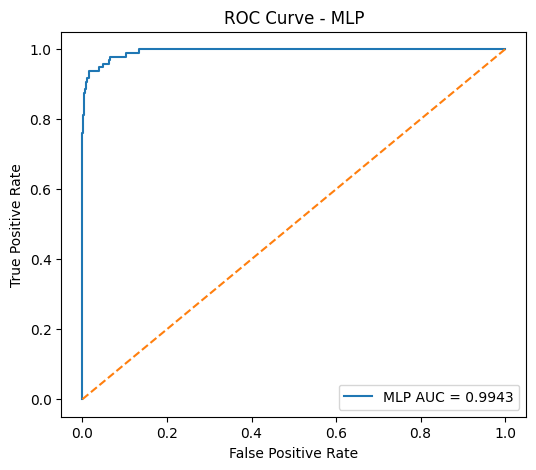

In [ ]:
# ================== RESULTS ==================
print("=== MLP (Deep Learning) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_MLP)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_MLP):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_MLP))

# ================== ROC CURVE ==================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_MLP)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"MLP AUC = {roc_auc_score(y_test, y_prob_MLP):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()
plt.show()


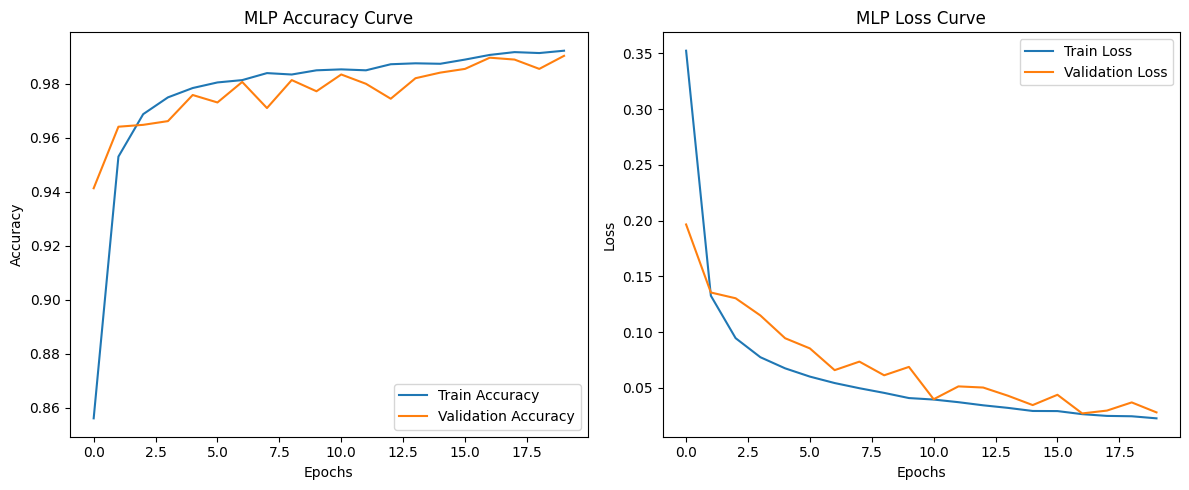

In [ ]:
plt.figure(figsize=(12,5))

# ================== Accuracy ==================
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('MLP Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ================== Loss ==================
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('MLP Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Confusion Matrix:
 [[889  15]
 [  6  90]]


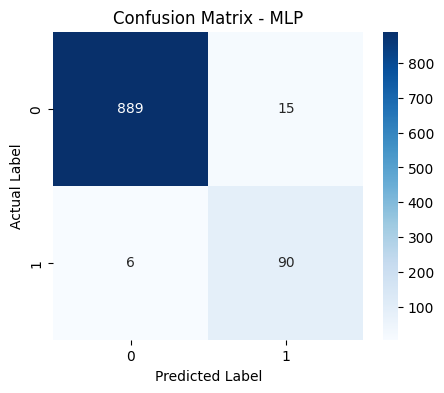

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_MLP)

print("Confusion Matrix:\n", cm)

# Heatmap visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - MLP")
plt.show()

In [ ]:
import pandas as pd

data = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "SVM",
        "MLP (Deep Learning)"
    ],
    "Accuracy": [0.908, 0.980, 0.988, 0.986, 0.988, 0.973, 0.977],
    "Precision": [0.51, 0.51, 0.90, 0.90, 0.93, 0.79, 0.87],
    "Recall": [0.92, 0.92, 0.99, 0.96, 0.95, 0.97, 0.90],
    "F1-score": [0.66, 0.66, 0.94, 0.93, 0.94, 0.87, 0.88],
    "ROC-AUC": [0.9674, 0.9963, 0.9993, 0.9991, 0.9990, 0.9940, 0.9921]
}

df = pd.DataFrame(data)
print(df)

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression     0.908       0.51    0.92      0.66   0.9674
1        Random Forest     0.980       0.51    0.92      0.66   0.9963
2    Gradient Boosting     0.988       0.90    0.99      0.94   0.9993
3              XGBoost     0.986       0.90    0.96      0.93   0.9991
4             LightGBM     0.988       0.93    0.95      0.94   0.9990
5                  SVM     0.973       0.79    0.97      0.87   0.9940
6  MLP (Deep Learning)     0.977       0.87    0.90      0.88   0.9921


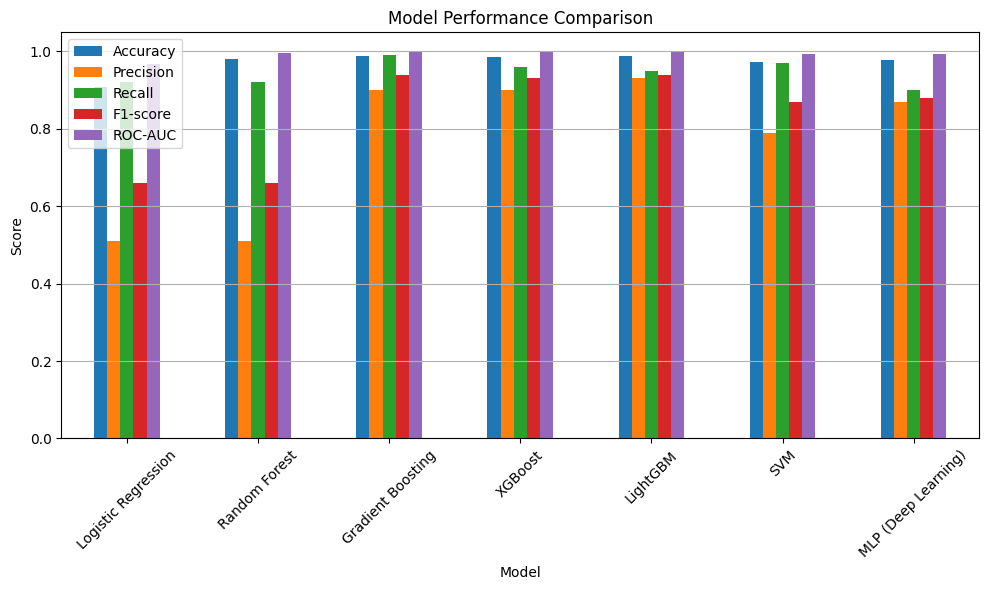

In [ ]:
import matplotlib.pyplot as plt

df.set_index("Model").plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()